In [1]:
import torch
print(torch.cuda.is_available())


True


In [2]:
!pip install torch torchvision pandas matplotlib scikit-learn tqdm


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd

df = pd.read_csv("published_images.csv")

print(df.columns)
df.head()


Index(['uuid', 'iiifurl', 'iiifthumburl', 'viewtype', 'sequence', 'width',
       'height', 'maxpixels', 'openaccess', 'created', 'modified',
       'depictstmsobjectid', 'assistivetext'],
      dtype='object')


,uuid,iiifurl,iiifthumburl,viewtype,sequence,width,height,maxpixels,openaccess,created,modified,depictstmsobjectid,assistivetext
0,00007f61-4922-417b-8f27-893ea328206c,https://api.nga.gov/iiif/00007f61-4922-417b-8f...,https://api.nga.gov/iiif/00007f61-4922-417b-8f...,primary,0,3365,4332,NaN,1,2013-07-05 15:41:08-04,2025-09-22 14:10:53-04,17387,NaN
1,0000bd8c-39de-4453-b55d-5e28a9beed38,https://api.nga.gov/iiif/0000bd8c-39de-4453-b5...,https://api.nga.gov/iiif/0000bd8c-39de-4453-b5...,primary,0,3500,4688,NaN,1,2013-08-05 14:31:59-04,2025-09-22 14:10:57-04,19245,NaN
2,0001668a-dd1c-48e8-9267-b6d1697d43c8,https://api.nga.gov/iiif/0001668a-dd1c-48e8-92...,https://api.nga.gov/iiif/0001668a-dd1c-48e8-92...,primary,0,3446,4448,NaN,1,2014-01-02 14:50:50-05,2025-09-22 14:11:18-04,23830,NaN
3,0002e210-8bc2-4471-bb0b-e7bb51d01a40,https://api.nga.gov/iiif/0002e210-8bc2-4471-bb...,https://api.nga.gov/iiif/0002e210-8bc2-4471-bb...,primary,0,2000,1571,900.0,0,2009-12-10 17:28:05-05,2026-01-01 07:14:56.937-05,232817,NaN
4,00032658-8a7a-44e3-8bb8-df8c172f521d,https://api.nga.gov/iiif/00032658-8a7a-44e3-8b...,https://api.nga.gov/iiif/00032658-8a7a-44e3-8b...,primary,0,2674,3798,NaN,1,2010-10-13 15:37:25-04,2026-02-11 09:02:19-05,713,NaN


In [9]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.CIFAR10(root='./data', download=True, transform=transform)


100%|██████████| 200/200 [04:28<00:00,  1.34s/it]


In [10]:
import torch
import torchvision.models as models

model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

def get_embedding(img):
    with torch.no_grad():
        emb = model(img.unsqueeze(0))
    return emb.flatten().numpy()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.CIFAR10(root='./data', download=True, transform=transform)


100%|██████████| 170M/170M [00:49<00:00, 3.47MB/s]


In [13]:
import torch
import torchvision.models as models

model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [14]:
def get_embedding(img):
    with torch.no_grad():
        emb = model(img.unsqueeze(0))
    return emb.flatten().numpy()


In [15]:
import numpy as np

embeddings = []
images = []

for i in range(200):
    img, label = dataset[i]
    embeddings.append(get_embedding(img))
    images.append(img)

embeddings = np.array(embeddings)


In [16]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

sim = cosine_similarity(embeddings)

def show_similar(query_idx, top_k=5):
    similar_indices = sim[query_idx].argsort()[-top_k-1:-1][::-1]

    plt.figure(figsize=(12,3))

    # Query image
    plt.subplot(1, top_k+1, 1)
    plt.imshow(images[query_idx].permute(1,2,0))
    plt.title("Query")
    plt.axis('off')

    # Similar images
    for i, idx in enumerate(similar_indices):
        plt.subplot(1, top_k+1, i+2)
        plt.imshow(images[idx].permute(1,2,0))
        plt.title(f"Sim: {sim[query_idx][idx]:.2f}")
        plt.axis('off')

    plt.show()


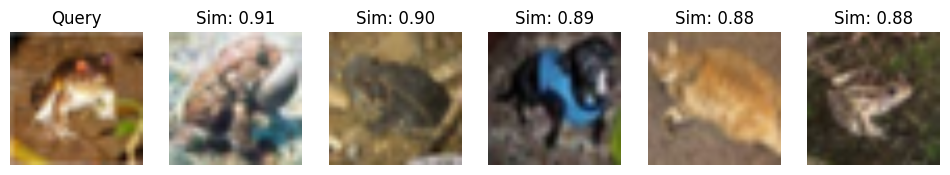

In [17]:
show_similar(0)


In [18]:
print(sim[0].max(), sim[0].min())


0.99999976 0.6222115


In [19]:
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-y8rg2kfd
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-y8rg2kfd
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=8414278d7dfc5b7d9c1c1c1e713226f8b1da0484ad6409fc93ba260457c191c6
  Stored in directory: /tmp/pip-ephem-wheel-cache-qrrbiw20/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [20]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()


100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 55.6MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [22]:
import torchvision.datasets as datasets

dataset = datasets.CIFAR10(
    root='./data',
    download=True,
    transform=preprocess
)


In [23]:
import numpy as np

embeddings = []
images = []
labels = []

for i in range(200):  # keep small
    img, label = dataset[i]

    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_image(img_input)

    embeddings.append(emb.cpu().numpy().flatten())
    images.append(img)   # keep for visualization
    labels.append(label)

embeddings = np.array(embeddings)


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(embeddings)


In [25]:
import matplotlib.pyplot as plt

def show_similar(query_idx, top_k=5):
    similar_indices = sim[query_idx].argsort()[-top_k-1:-1][::-1]

    plt.figure(figsize=(12,3))

    # Query
    plt.subplot(1, top_k+1, 1)
    plt.imshow(images[query_idx].permute(1,2,0))
    plt.title("Query")
    plt.axis('off')

    # Results
    for i, idx in enumerate(similar_indices):
        plt.subplot(1, top_k+1, i+2)
        plt.imshow(images[idx].permute(1,2,0))
        plt.title(f"{sim[query_idx][idx]:.2f}")
        plt.axis('off')

    plt.show()


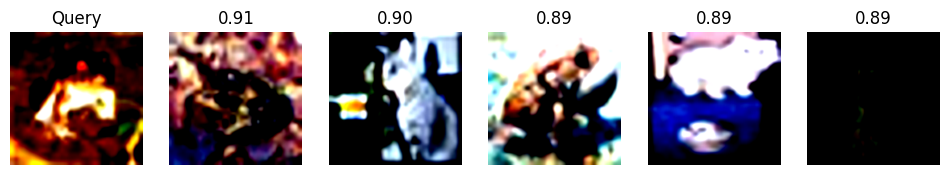

In [26]:
show_similar(0)


In [27]:
same_class = []
diff_class = []

for i in range(100):
    for j in range(i+1, 100):
        if labels[i] == labels[j]:
            same_class.append(sim[i][j])
        else:
            diff_class.append(sim[i][j])

print("Same class avg similarity:", sum(same_class)/len(same_class))
print("Different class avg similarity:", sum(diff_class)/len(diff_class))


Same class avg similarity: 0.8253408682227593
Different class avg similarity: 0.747512127086003


In [28]:
from sklearn.preprocessing import normalize

embeddings = normalize(embeddings)
sim = cosine_similarity(embeddings)


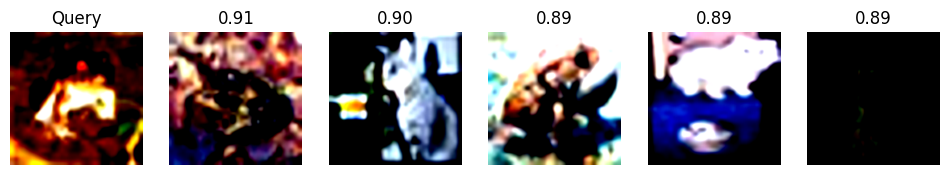

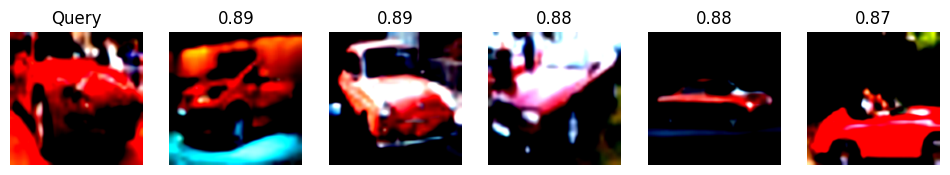

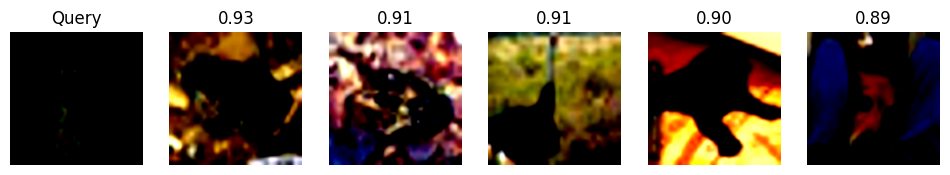

In [29]:
for i in [0, 5, 10]:
    show_similar(i)
